# 1. 数据准备

In [1]:
! wget https://www.dropbox.com/s/6l2vcvxl54b0b6w/food11.zip
! unzip food11.zip

--2026-04-11 04:13:31--  https://www.dropbox.com/s/6l2vcvxl54b0b6w/food11.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.71.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.71.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/hjgabr8fbuvuzjvtp77b1/food11.zip?rlkey=nsgokn3hjmer9ss6p1v9aag98 [following]
--2026-04-11 04:13:32--  https://www.dropbox.com/scl/fi/hjgabr8fbuvuzjvtp77b1/food11.zip?rlkey=nsgokn3hjmer9ss6p1v9aag98
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucacdaed43a3cab871a94dbaf06a.dl.dropboxusercontent.com/cd/0/inline/C-WRIT5PStaBJRnYiNA1kG754UO2ivI4XQOsXdzQsAVGaX311y0WjCx7L0-HGbU9MDDmfQW-TPjgbuh7fkMrnmfy_JyseVfhhQwCo2T4WYqq5NXKefyBEx37nl2lGmQBePmb6JlbnJs2cjFxTtxVqpdQ/file# [following]
--2026-04-11 04:13:33--  https://ucacdaed43a3cab871a94dbaf06a.dl.dropboxusercontent.com/cd/0/inline/C-WRI

# 2. 保证复现

In [3]:
import numpy as np
import torch
seed = 1
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(seed)
if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed_all(seed)
    print(f"使用{torch.cuda.get_device_name()}")
else:
    device = 'cpu'
    print(f"正在使用cpu")


使用Tesla T4


# 2. 定义Transform (图片处理)

In [4]:
from torchvision.transforms import transforms
training_tfm = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet 归一化
])
test_tfm = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
help(transforms.Normalize)

Help on class Normalize in module torchvision.transforms.transforms:

class Normalize(torch.nn.modules.module.Module)
 |  Normalize(mean, std, inplace=False)
 |
 |  Normalize a tensor image with mean and standard deviation.
 |  This transform does not support PIL Image.
 |  Given mean: ``(mean[1],...,mean[n])`` and std: ``(std[1],..,std[n])`` for ``n``
 |  channels, this transform will normalize each channel of the input
 |  ``torch.*Tensor`` i.e.,
 |  ``output[channel] = (input[channel] - mean[channel]) / std[channel]``
 |
 |  .. note::
 |      This transform acts out of place, i.e., it does not mutate the input tensor.
 |
 |  Args:
 |      mean (sequence): Sequence of means for each channel.
 |      std (sequence): Sequence of standard deviations for each channel.
 |      inplace(bool,optional): Bool to make this operation in-place.
 |
 |  Method resolution order:
 |      Normalize
 |      torch.nn.modules.module.Module
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __in

# 3. Dataset 

In [6]:
from torch.utils.data import Dataset
import os
from PIL import Image
class FoodDataset(Dataset):
    def __init__(self, path, tfm = training_tfm, files = None):
        super().__init__()
        if files is not None:
            self.files = files
        else:
            self.files = sorted([os.path.join(path, x) for x in os.listdir(path) if x.endswith('.jpg')])
        self.tfm = tfm
        print(self.files)
    def __getitem__(self,idx):
        im = Image.open(self.files[idx])
        im = self.tfm(im)
        try:
            data = im
            labels = int(self.files[idx].split('/')[-1].split('_')[0])
        except:
            labels = -1
        return data, labels       
    
    def __len__(self):
        return len(self.files)


In [7]:
trainset = FoodDataset('./food11/training')
validset = FoodDataset('./food11/validation', tfm=test_tfm)

['./food11/training/0_0.jpg', './food11/training/0_1.jpg', './food11/training/0_10.jpg', './food11/training/0_100.jpg', './food11/training/0_101.jpg', './food11/training/0_102.jpg', './food11/training/0_103.jpg', './food11/training/0_104.jpg', './food11/training/0_105.jpg', './food11/training/0_106.jpg', './food11/training/0_107.jpg', './food11/training/0_108.jpg', './food11/training/0_109.jpg', './food11/training/0_11.jpg', './food11/training/0_110.jpg', './food11/training/0_111.jpg', './food11/training/0_112.jpg', './food11/training/0_113.jpg', './food11/training/0_114.jpg', './food11/training/0_115.jpg', './food11/training/0_116.jpg', './food11/training/0_117.jpg', './food11/training/0_118.jpg', './food11/training/0_119.jpg', './food11/training/0_12.jpg', './food11/training/0_120.jpg', './food11/training/0_121.jpg', './food11/training/0_122.jpg', './food11/training/0_123.jpg', './food11/training/0_124.jpg', './food11/training/0_125.jpg', './food11/training/0_126.jpg', './food11/trai

# 4. 产生Dataloader

In [8]:
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(validset,batch_size=batch_size,shuffle=True, num_workers=4, pin_memory = True)
print(f"训练数据：{len(train_loader.dataset)}")
print(f"训练数据batch数量{len(train_loader)}")


训练数据：9866
训练数据batch数量155


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# 5. Model

In [15]:
import torchvision
import torchvision.models as models
import torch.nn as nn
def make_model(num_class = 11):
    model = models.resnet50(pretrained = False)
    print(f"fc全连接 {model.fc}") ### fc是model（实例）的一个属性，与此同时本身也是一个实例（nn.Linear类实例化产生）
    print(f"{model.fc.in_features}")
    in_features = model.fc.in_features # 实例的属性fc，因为fc也是实例，也有属性in_features，最后in_features 也是属性 （int实例化出的）
    model.fc = nn.Linear(in_features, num_class) ### 重新实例化
    return model
model = make_model(11).to(device)
print(f"参数总量为 {sum([p.numel() for p in model.parameters() ])}") ###
print(f"需要梯度的参数总量 {sum([p.numel() for p in model.parameters() if p.requires_grad])}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


fc全连接 Linear(in_features=2048, out_features=1000, bias=True)
2048
参数总量为 23530571
需要梯度的参数总量 23530571


# 6. 定义损失和优化器

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.0001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer,step_size=30,gamma=0.1)

# 7. 训练过程

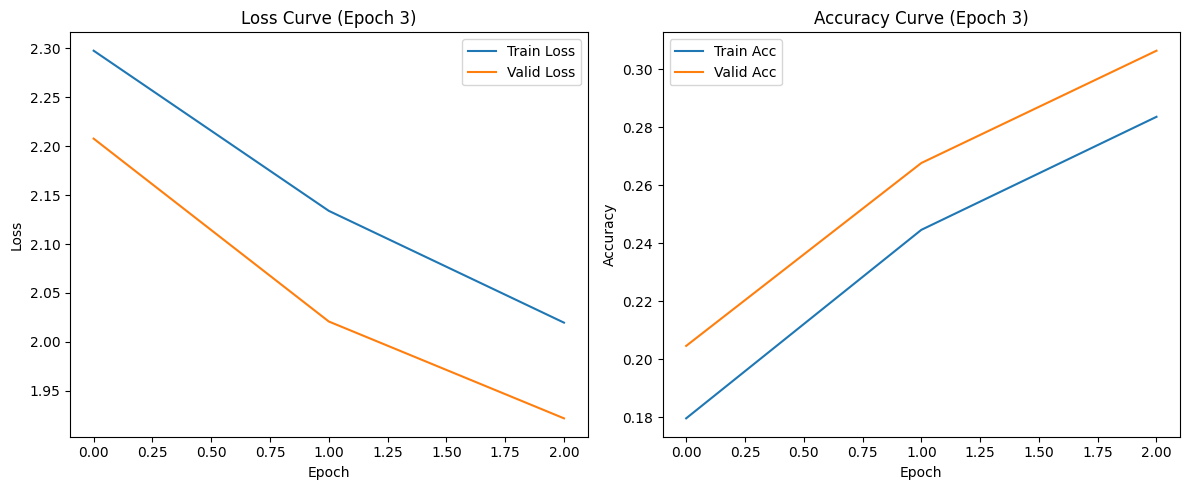

 69%|██████▊   | 37/54 [00:11<00:04,  3.48it/s]

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
num_epochs = 100
count = 0
early_stop = 10
train_losses, train_accs, valid_losses, valid_accs = [], [], [], []
best_acc = 0
model_path = './models/model.pt'
if not os.path.exists('./models') :
    os.mkdir('./models')
for epoch in range(num_epochs):
    train_loss = 0
    train_acc = 0
    model.train()
    for _, batch in enumerate(tqdm(train_loader)):
        features, labels = batch
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
        optimizer.step()
        _, pred = torch.max(logits, dim = 1)
        train_loss += loss.detach().cpu().item()
        train_acc += (pred.detach() == labels).float().mean().item()
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    if len(valid_loader) > 0:
        model.eval()
        valid_loss = 0
        valid_acc = 0
        with torch.no_grad():
            for _, batch in enumerate(tqdm(valid_loader)):
                features, labels = batch
                features, labels = features.to(device), labels.to(device)
                logits = model(features)
                loss = criterion(logits, labels)
                _, pred = torch.max(logits, dim = 1)
                valid_loss += loss.item()
                valid_acc += (pred == labels).float().mean().item()
            valid_loss /= len(valid_loader)
            valid_acc /= len(valid_loader)
        valid_losses.append(valid_loss)
        valid_accs.append(valid_acc)

        if valid_acc > best_acc:
            best_acc = valid_acc
            torch.save(model.state_dict(), f = model_path)
            print(f"Saving model with best acc {best_acc}...")
            count = 0
        else:
            count += 1
            if count >= early_stop:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']
    print(f"Learning Rate: {cur_lr:.6f}")

    # ===== 每隔 10 个 epoch 刷新一次图 =====
    if (epoch + 1) % 1 == 0 or epoch == 0:
        clear_output(wait=True)   # 清掉上一个图，不重刷整个页面
        
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        if valid_losses:
            plt.plot(valid_losses, label='Valid Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title(f'Loss Curve (Epoch {epoch+1})')
        
        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Train Acc')
        if valid_accs:
            plt.plot(valid_accs, label='Valid Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.title(f'Accuracy Curve (Epoch {epoch+1})')
        
        plt.tight_layout()
        plt.show()

# 8. 加载最优模型和预测

In [ ]:
del model
model = make_model(11).to(device)
model.load_state_dict(torch.load(f = './models/model.pt'))
testdata = FoodDataset('./food11/test',tfm=test_tfm)
testloader = DataLoader(testdata, batch_size= batch_size, shuffle= False, num_workers=4, pin_memory=True)
preds = []
model.eval()
for x,y  in testloader:
    x,y = x.to(device), y.to(device)
    with torch.no_grad():
        logits = model(x)
        _,pred = torch.max(logits,dim = 1)
    preds.append(pred.cpu().numpy())
prediction = np.concatenate(preds)